# PHYS 449 - Homework 6, Question 3

**Student Name:** Allen Mathew \
**Student ID:** 20964892 \
**Due Date:** Thursday, November 6, 3:00pm 

*ChatGPT was used to help generate the code*
- - -


3. Train an RBM on the MNIST dataset using Contrastive Divergence (CD-$k$).

(a) Experiment with hyperparameters (number of hidden units, learning rate, value of $k$, batch size, etc.) to get good performance. Plot the log likelihood as a function of training epoch to justify your choices.

Epoch 01 PLL=-155.347
Epoch 02 PLL=-74.578
Epoch 03 PLL=-119.086
Epoch 04 PLL=-103.060
Epoch 05 PLL=-98.743
Epoch 06 PLL=-70.534
Epoch 07 PLL=-77.610
Epoch 08 PLL=-133.786
Epoch 09 PLL=-72.415
Epoch 10 PLL=-73.889


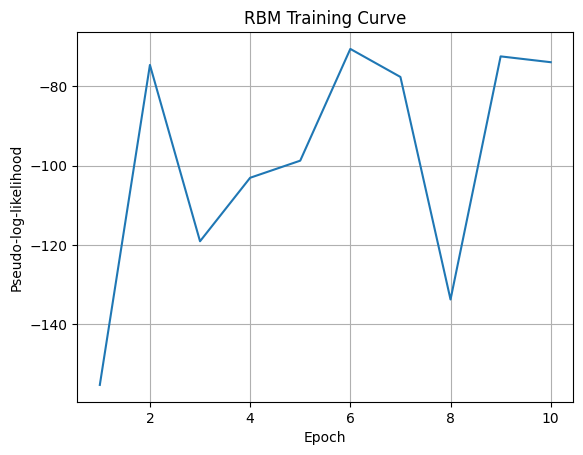

In [4]:
# === Q3(a): Training RBM on MNIST (hyperparameter tuning and PLL plot) ===
import torch, math, numpy as np, matplotlib.pyplot as plt
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0); np.random.seed(0)

# --- Load and binarize MNIST ---
transform = transforms.ToTensor()
train_data = datasets.MNIST("./data", train=True, download=True, transform=transform)
test_data  = datasets.MNIST("./data", train=False, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=128, shuffle=True, drop_last=True)
test_loader  = DataLoader(test_data, batch_size=128, shuffle=False)
D = 28*28

def binarize(x): return torch.bernoulli(x)

# --- RBM class ---
class RBM(nn.Module):
    def __init__(self, n_visible, n_hidden):
        super().__init__()
        self.W = nn.Parameter(0.01*torch.randn(n_visible, n_hidden))
        self.a = nn.Parameter(torch.zeros(n_visible))
        self.b = nn.Parameter(torch.zeros(n_hidden))
    def sample_h(self, v):
        p = torch.sigmoid(v @ self.W + self.b)
        return torch.bernoulli(p), p
    def sample_v(self, h):
        p = torch.sigmoid(h @ self.W.t() + self.a)
        return torch.bernoulli(p), p
    def free_energy(self, v):
        term = torch.log1p(torch.exp(v @ self.W + self.b)).sum(1)
        return -v@self.a - term
    def pseudo_log_likelihood(self, v):
        bsz = v.size(0)
        i = torch.randint(0, v.size(1), (bsz,), device=v.device)
        v2 = v.clone(); v2[torch.arange(bsz), i] = 1 - v2[torch.arange(bsz), i]
        return (v.size(1)*torch.log(torch.sigmoid(self.free_energy(v2)-self.free_energy(v)))).mean()

def train_rbm(epochs=10, n_hidden=256, lr=1e-3, k=1):
    rbm = RBM(D, n_hidden).to(device)
    opt = torch.optim.Adam(rbm.parameters(), lr=lr)
    pll_hist = []
    for ep in range(1, epochs+1):
        for (x, _) in train_loader:
            v0 = binarize(x.view(-1, D).to(device))
            h0, _ = rbm.sample_h(v0)
            vk = v0
            for _ in range(k):
                hk, _ = rbm.sample_h(vk)
                vk, _ = rbm.sample_v(hk)
            ph0 = torch.sigmoid(v0 @ rbm.W + rbm.b)
            phk = torch.sigmoid(vk @ rbm.W + rbm.b)
            dW = (v0.t()@ph0 - vk.t()@phk)/v0.size(0)
            da = (v0 - vk).mean(0); db = (ph0 - phk).mean(0)
            rbm.W.grad, rbm.a.grad, rbm.b.grad = -dW, -da, -db
            opt.step(); opt.zero_grad(set_to_none=True)
        with torch.no_grad():
            x_val, _ = next(iter(test_loader))
            pll = rbm.pseudo_log_likelihood(binarize(x_val.view(-1, D).to(device))).item()
        pll_hist.append(pll); print(f"Epoch {ep:02d} PLL={pll:.3f}")
    plt.plot(range(1, epochs+1), pll_hist)
    plt.xlabel("Epoch"); plt.ylabel("Pseudo-log-likelihood")
    plt.title("RBM Training Curve"); plt.grid(True); plt.show()
    return rbm

rbm = train_rbm(epochs=10, n_hidden=256, lr=1e-3, k=1)


(b) Generate samples of digits from $0$ to $9$ using Block Gibbs sampling from the trained model. Did your model generalize well?

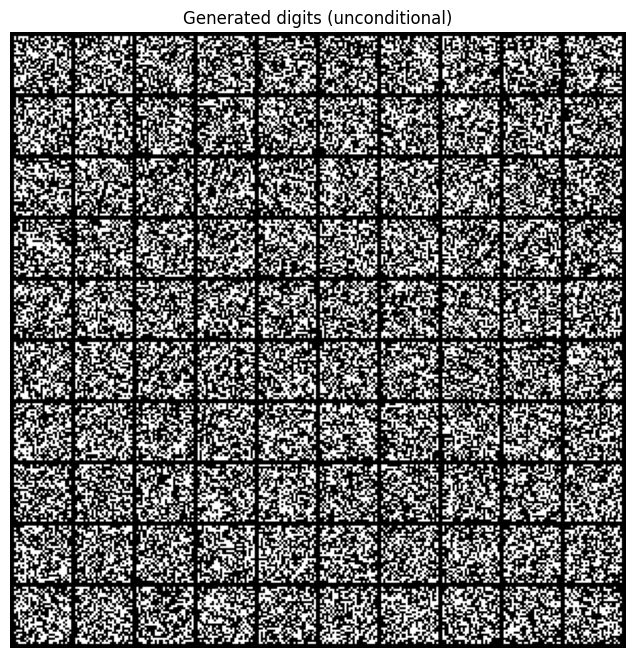

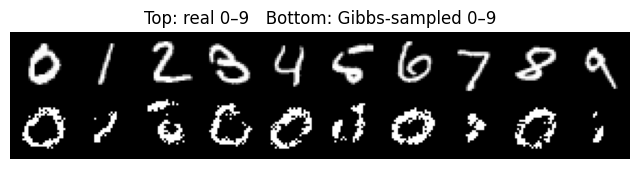

In [5]:
# === Q3(b): Sampling digits 0–9 with Block Gibbs ===
from torchvision import utils as tvutils

def show_grid(imgs, nrow=10, title=None):
    grid = tvutils.make_grid(imgs, nrow=nrow, padding=2)
    plt.figure(figsize=(8,8)); plt.axis("off")
    if title: plt.title(title)
    plt.imshow(grid.permute(1,2,0).cpu().numpy()); plt.show()

@torch.no_grad()
def sample_digits(rbm, n_samples=100, steps=500):
    v = torch.bernoulli(0.5*torch.ones(n_samples, rbm.W.size(0), device=device))
    for _ in range(steps):
        h, _ = rbm.sample_h(v); v, _ = rbm.sample_v(h)
    return v.view(-1,1,28,28).cpu()

samples = sample_digits(rbm, n_samples=100, steps=500)
show_grid(samples[:100], nrow=10, title="Generated digits (unconditional)")

# --- seed each chain with a real example 0–9 ---
@torch.no_grad()
def pick_one_per_digit(dataset):
    out=[]
    for d in range(10):
        for x,y in dataset:
            if y==d: out.append(x); break
    return torch.stack(out)

seeds = pick_one_per_digit(datasets.MNIST("./data",train=False,transform=transforms.ToTensor()))
v = binarize(seeds.view(10,-1).to(device))
for _ in range(200):
    h,_ = rbm.sample_h(v); v,_ = rbm.sample_v(h)
grid = torch.cat([seeds,v.view(-1,1,28,28).cpu()],0)
show_grid(grid,nrow=10,title="Top: real 0–9 Bottom: Gibbs-sampled 0–9")


(c) For each hidden unit, reshape its weights into a $28 \times 28$ matrix and plot. Discuss any features descendent from the original images captured by the hidden units.

C:\Users\Allen\AppData\Local\Temp\ipykernel_5408\1735787205.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  imgs = torch.tensor(W).view(-1, 1, 28, 28)


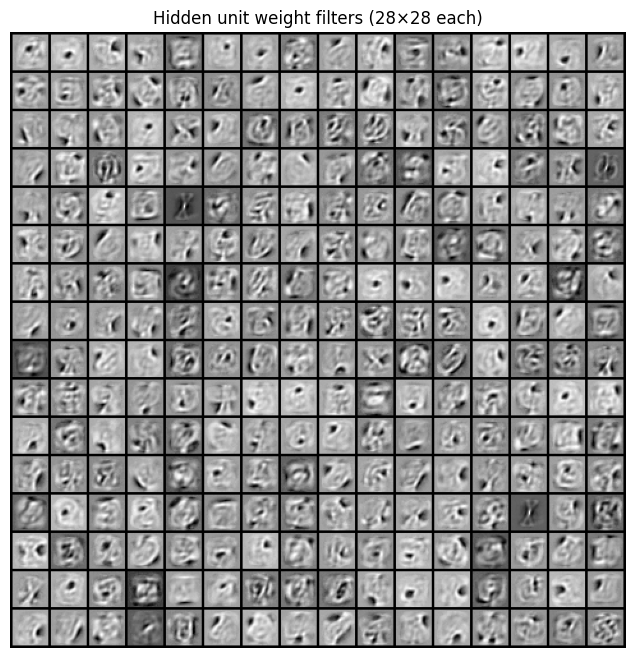

In [7]:
# === Q3(c): Visualize hidden-unit filters (fixed version) ===
W = rbm.W.detach().cpu().T
imgs = torch.tensor(W).view(-1, 1, 28, 28)

# normalize each filter using torch.amin / torch.amax
mins = torch.amin(imgs, dim=(2, 3), keepdim=True)
maxs = torch.amax(imgs, dim=(2, 3), keepdim=True)
imgs = (imgs - mins) / (maxs - mins + 1e-8)

side = int(math.ceil(math.sqrt(imgs.size(0))))
show_grid(imgs, nrow=side, title="Hidden unit weight filters (28×28 each)")

